In [ ]:
# Upload, Preprocess, Train CNN for Tumor Classification (Benign vs Malignant)
from google.colab import files
import zipfile, os, numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

In [ ]:
# 1. Upload dataset ZIP file
print("Upload your dataset ZIP (containing train/, val/, test/ folders)")
uploaded = files.upload()


Upload your dataset ZIP (containing train/, val/, test/ folders)


Saving DataSet.zip to DataSet.zip


In [ ]:
# 2. Extract ZIP file
for zip_file in uploaded.keys():
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall("dataset")


In [ ]:
# 3. Set dataset paths
base_dir = "dataset"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

#  1. Image size and batch
IMG_SIZE = (128, 128)
BATCH_SIZE = 16

#  2. Enhanced Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.25,
    horizontal_flip=True,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

#  3. Data loading
train_data = train_datagen.flow_from_directory("dataset/train", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
val_data = val_test_datagen.flow_from_directory("dataset/val", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
test_data = val_test_datagen.flow_from_directory("dataset/test", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

# 4. Load MobileNetV2 & Unfreeze last 30 layers
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
for layer in base_model.layers[:-30]:  # Unfreeze more layers
    layer.trainable = False

#  5. Build Model with BatchNorm
model = tf.keras.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

#  6. Compile
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

#  7. Train longer + callbacks
early_stop = EarlyStopping(patience=4, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-6)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=12,  # Train longer
    callbacks=[early_stop, lr_scheduler]
)

#  8. Evaluate
test_loss, test_acc = model.evaluate(test_data)
print(f" Final Test Accuracy: {test_acc:.4f}")

#  9. Save model
model.save("tumor_mobilenet_80plus.keras")


Found 3816 images belonging to 2 classes.
Found 1908 images belonging to 2 classes.
Found 1908 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 110s 408ms/step - accuracy: 0.5822 - loss: 0.8751 - val_accuracy: 0.3690 - val_loss: 1.5207 - learning_rate: 1.0000e-04
Epoch 2/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 94s 392ms/step - accuracy: 0.6572 - loss: 0.7248 - val_accuracy: 0.4775 - val_loss: 1.5201 - learning_rate: 1.0000e-04
Epoch 3/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 93s 389ms/step - accuracy: 0.6957 - loss: 0.6606 - val_accuracy: 0.6567 - val_loss: 0.7091 - learning_rate: 1.0000e-04
Epoch 4/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 94s 395ms/step - accuracy: 0.6989 - loss: 0.6201 - val_accuracy: 0.5865 - val_loss: 1.0256 - learning_rate: 1.0000e-04
Epoch 5/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 143s 399ms/step - accuracy: 0.7350 - loss: 0.5827 - val_accuracy: 0.6887 - val_loss: 0.7050 - learning_rate: 1.0000e-04
Epoch 6/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 96s 403ms/step - accuracy: 0.7372 - loss: 0.5579 - val_accuracy: 0.7746 - val_loss: 0.5148 - learning_rate: 1.0000e-04
Epoch 7/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 96s 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Predict probabilities
y_probs = model.predict(test_data)
y_pred = (y_probs > 0.5).astype(int).flatten()  # Convert to binary

# True labels
y_true = test_data.classes


120/120 ━━━━━━━━━━━━━━━━━━━━ 23s 173ms/step


In [ ]:
print("📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_data.class_indices.keys()))


📊 Classification Report:
              precision    recall  f1-score   support

      Benign       0.88      0.62      0.73       630
   Malignant       0.84      0.96      0.89      1278

    accuracy                           0.85      1908
   macro avg       0.86      0.79      0.81      1908
weighted avg       0.85      0.85      0.84      1908



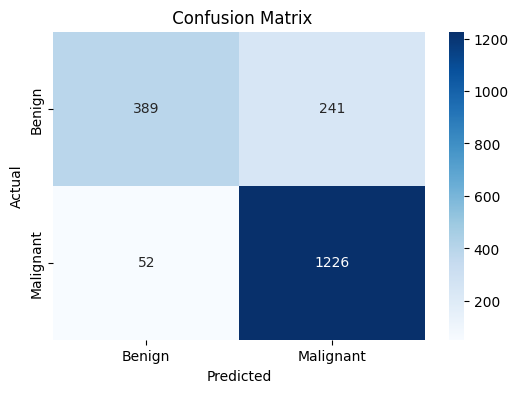

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.class_indices.keys(),
            yticklabels=test_data.class_indices.keys())
plt.title(' Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


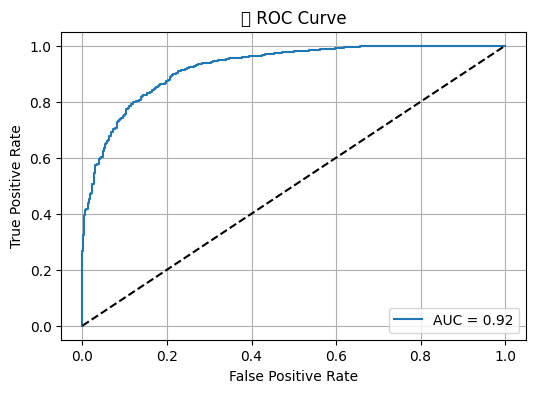

In [ ]:
# Only works if you have probability predictions
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = roc_auc_score(y_true, y_probs)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('📈 ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


 Choose an image to predict (e.g., tumor1.jpg)


Saving breastcancerimage.jpg to breastcancerimage.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


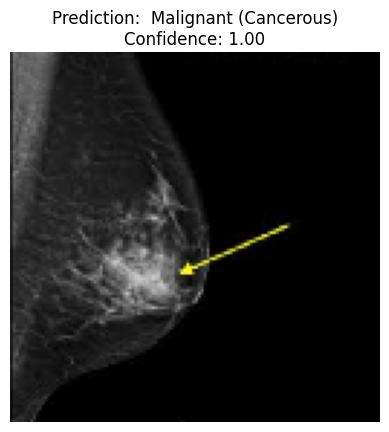

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
from google.colab import files

#  Load the trained model
model = load_model("tumor_mobilenet_80plus.keras")  # Change if your filename is different

#  Upload an image
print(" Choose an image to predict (e.g., tumor1.jpg)")
uploaded = files.upload()

#  Preprocess the image
image_path = list(uploaded.keys())[0]
img = load_img(image_path, target_size=(128, 128))  # Same size used in training
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

#  Predict
prediction = model.predict(img_array)[0][0]

#  Interpret prediction
if prediction < 0.5:
    result = " Benign (Non-cancerous)"
    confidence = 1 - prediction
else:
    result = " Malignant (Cancerous)"
    confidence = prediction

#  Show image and prediction
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {result}\nConfidence: {confidence:.2f}")
plt.show()


***EFFICIENT NET B0***

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Image size and batch
IMG_SIZE = (128, 128)
BATCH_SIZE = 16

# 2. Enhanced Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.25,
    horizontal_flip=True,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Data loading
train_data = train_datagen.flow_from_directory("dataset/train", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
val_data = val_test_datagen.flow_from_directory("dataset/val", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
test_data = val_test_datagen.flow_from_directory("dataset/test", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

# 4. Load EfficientNetB0 & unfreeze last 30 layers
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
for layer in base_model.layers[:-30]:
    layer.trainable = False

# 5. Build model
model = tf.keras.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# 6. Compile
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# 7. Train with callbacks
early_stop = EarlyStopping(patience=4, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-6)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=12,
    callbacks=[early_stop, lr_scheduler]
)

# 8. Evaluate
test_loss, test_acc = model.evaluate(test_data)
print(f" Final Test Accuracy: {test_acc:.4f}")

# 9. Save model
model.save("efficientnet_80plus.keras")


Found 3816 images belonging to 2 classes.
Found 1908 images belonging to 2 classes.
Found 1908 images belonging to 2 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 180s 651ms/step - accuracy: 0.5120 - loss: 0.9559 - val_accuracy: 0.6698 - val_loss: 0.6619 - learning_rate: 1.0000e-04
Epoch 2/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 146s 610ms/step - accuracy: 0.5440 - loss: 0.8887 - val_accuracy: 0.3302 - val_loss: 0.7138 - learning_rate: 1.0000e-04
Epoch 3/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 207s 631ms/step - accuracy: 0.5628 - loss: 0.8635 - val_accuracy: 0.3302 - val_loss: 0.7573 - learning_rate: 1.0000e-04
Epoch 4/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 152s 636ms/step - accuracy: 0.5838 - loss: 0.8344 - val_accuracy: 0.3302 - val_loss: 0.7367 - learning_rate: 5.0000e-05
Epoch 5/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 141s 590ms/step - accuracy: 0.5842 - loss: 0.7966 - val_accuracy: 0.6698 - val_loss: 0.6495 - learning_rate: 5.0000e-05
Epoch 6/12
239/239 ━━━━

120/120 ━━━━━━━━━━━━━━━━━━━━ 22s 172ms/step


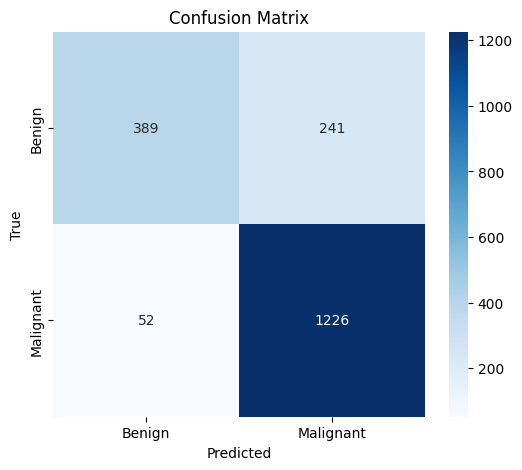


Classification Report:
              precision    recall  f1-score   support

      Benign       0.88      0.62      0.73       630
   Malignant       0.84      0.96      0.89      1278

    accuracy                           0.85      1908
   macro avg       0.86      0.79      0.81      1908
weighted avg       0.85      0.85      0.84      1908



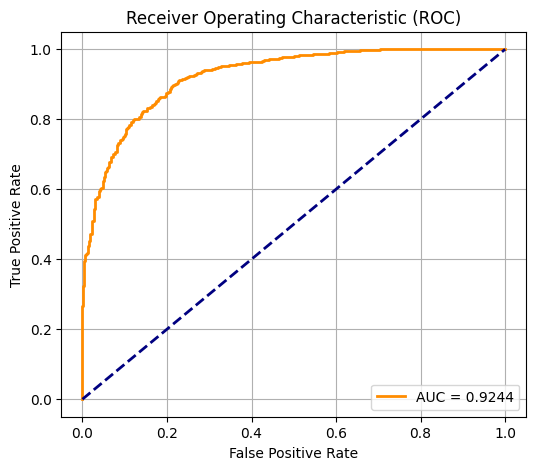

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

# 1. Get true labels and predicted probabilities
y_true = test_data.classes
y_probs = model.predict(test_data)  # Probabilities
y_pred = (y_probs > 0.5).astype("int32").flatten()  # Binary predictions

# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_data.class_indices, yticklabels=test_data.class_indices)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 3. Classification Report (Optional)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_data.class_indices))

# 4. ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='AUC = %0.4f' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.grid()
plt.show()


***RESTNET50***

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Image size and batch
IMG_SIZE = (128, 128)
BATCH_SIZE = 16

# 2. Enhanced Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.25,
    horizontal_flip=True,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Data loading
train_data = train_datagen.flow_from_directory("dataset/train", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
val_data = val_test_datagen.flow_from_directory("dataset/val", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
test_data = val_test_datagen.flow_from_directory("dataset/test", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

# 4. Load ResNet50 & unfreeze last 30 layers
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
for layer in base_model.layers[:-30]:
    layer.trainable = False

# 5. Build model
model = tf.keras.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# 6. Compile
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# 7. Train with callbacks
early_stop = EarlyStopping(patience=4, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-6)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=12,
    callbacks=[early_stop, lr_scheduler]
)

# 8. Evaluate
test_loss, test_acc = model.evaluate(test_data)
print(f" Final Test Accuracy: {test_acc:.4f}")

# 9. Save model
model.save("resnet50_80plus.keras")


Found 3816 images belonging to 2 classes.
Found 1908 images belonging to 2 classes.
Found 1908 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/12


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


239/239 ━━━━━━━━━━━━━━━━━━━━ 483s 2s/step - accuracy: 0.5229 - loss: 0.8893 - val_accuracy: 0.6698 - val_loss: 0.7542 - learning_rate: 1.0000e-04
Epoch 2/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 459s 2s/step - accuracy: 0.5738 - loss: 0.7344 - val_accuracy: 0.6698 - val_loss: 1.0817 - learning_rate: 1.0000e-04
Epoch 3/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 462s 2s/step - accuracy: 0.6004 - loss: 0.7001 - val_accuracy: 0.3302 - val_loss: 3.9846 - learning_rate: 1.0000e-04
Epoch 4/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 506s 2s/step - accuracy: 0.6361 - loss: 0.6841 - val_accuracy: 0.3302 - val_loss: 2.9615 - learning_rate: 5.0000e-05
Epoch 5/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 508s 2s/step - accuracy: 0.6209 - loss: 0.6927 - val_accuracy: 0.6703 - val_loss: 0.6443 - learning_rate: 5.0000e-05
Epoch 6/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 558s 2s/step - accuracy: 0.6136 - loss: 0.6943 - val_accuracy: 0.3302 - val_loss: 1.5340 - learning_rate: 5.0000e-05
Epoch 7/12
239/239 ━━━━━━━━━━━━━━━━━━━━ 502s 2s/step - accuracy: 0.62